In [55]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIRECTORY = "/home/lisa/Arupreza/UIDS/UIDS-II/Split_data/OtherLAB/Kia"


def normalize_can_id_by_frequency(df, column_name='CAN_ID'):
    id_counts = df[column_name].value_counts().reset_index()
    if len(id_counts.columns) == 2:
        id_counts.columns = [column_name, 'Count']

    def assign_category(count):
        if count >= 12000:
            return 1
        elif 5000 <= count < 12000:
            return 2
        elif 2500 <= count < 5000:
            return 3
        else:
            return 4

    id_counts['Category'] = id_counts['Count'].apply(assign_category)
    id_to_category_map = pd.Series(
        id_counts['Category'].values,
        index=id_counts[column_name]
    ).to_dict()

    df[f'{column_name}_Norm'] = df[column_name].map(id_to_category_map)
    return df


def IntraIDTimeGapNorm(value):
    if pd.isna(value):
        return -1
    if value <= 5.1:
        return 0
    elif value <= 10.1:
        return 1
    elif value <= 20.1:
        return 2
    elif value <= 30.1:
        return 3
    elif value <= 40.1:
        return 4
    elif value <= 50.1:
        return 5
    elif value <= 2010.1:
        return 6
    elif value <= 5010.1:
        return 7
    else:
        return 8


def TimeDeltaTimeGapNorm(value):
    if pd.isna(value):
        return -1
    if 0 <= value <= 0.05:
        return 0
    elif 0.05 < value <= 0.1:
        return 1
    elif 0.1 < value <= 0.2:
        return 2
    elif 0.2 < value <= 0.3:
        return 3
    elif 0.3 < value <= 0.4:
        return 4
    elif 0.4 < value <= 0.5:
        return 5
    else:
        return 6


def LoadPreprocessData(file_path):
    df = pd.read_csv(file_path, low_memory=False)

    if 'CAN_ID' not in df.columns or 'Time_Offset' not in df.columns:
        return None

    df = normalize_can_id_by_frequency(df)
    df['Time_Delta'] = df['Time_Offset'].diff()
    df['Intra_ID_Time_Gap'] = df.groupby('CAN_ID')['Time_Offset'].diff()

    df.dropna(subset=['Time_Delta', 'Intra_ID_Time_Gap'], inplace=True)
    df.reset_index(drop=True, inplace=True)

    if 'Label' not in df.columns:
        df['Label'] = 'Normal'

    df['Time_Delta_Norm'] = df['Time_Delta'].apply(TimeDeltaTimeGapNorm)
    df['Intra_ID_Time_Gap_Norm'] = df['Intra_ID_Time_Gap'].apply(IntraIDTimeGapNorm)

    return df


def get_one_chunk_per_category(root_dir, use_norm=True, max_len=1000):
    """
    Rule:
    - all Kia_AF.csv -> Normal
    - all other csv   -> folder name category
    """
    category_chunks = {}

    csv_files = glob.glob(os.path.join(root_dir, "**", "*.csv"), recursive=True)

    for file_path in sorted(csv_files):
        rel_path = os.path.relpath(file_path, root_dir)
        parts = rel_path.split(os.sep)

        if len(parts) < 2:
            continue

        folder_category = parts[0]
        filename = os.path.basename(file_path)

        # Put all attack-free files into one Normal category
        if filename == "Kia_AF.csv":
            category = "Normal"
        else:
            category = folder_category

        df = LoadPreprocessData(file_path)
        if df is None or df.empty:
            continue

        if use_norm:
            arr = df[['Time_Delta_Norm', 'Intra_ID_Time_Gap_Norm']].values.astype(int)
        else:
            arr = df[['Time_Delta', 'Intra_ID_Time_Gap']].values

        category_chunks.setdefault(category, []).append(arr)

    for category in category_chunks:
        merged = np.vstack(category_chunks[category])
        if max_len is not None:
            merged = merged[:max_len]
        category_chunks[category] = merged

    return category_chunks

In [56]:
# === RUN ===
category_chunks = get_one_chunk_per_category(
    DATA_DIRECTORY,
    use_norm=True,
    max_len=250
)

In [57]:
import matplotlib.pyplot as plt
import numpy as np

def plot_category_chunks_shared_ylabel(
    category_chunks,
    feature_idx=0,
    shared_ylabel="Time Delta Normalization",
    figsize=(10, 12),
    x_tick_step=50
):
    desired_order = ["Normal", "DoS", "Fuzz", "Gear Spoofing", "Malfunction", "RPM Spoofing", "Replay"]
    categories = [c for c in desired_order if c in category_chunks]

    color_map = {
        "Normal": "tab:blue",
        "DoS": "tab:red",
        "Fuzz": "tab:blue",
        "Gear Spoofing": "tab:orange",
        "Malfunction": "tab:purple",
        "RPM Spoofing": "tab:pink",
        "Replay": "tab:green",
    }

    if feature_idx == 0:
        y_ticks = np.arange(0, 8, 1)    # 0 ~ 7
        y_min, y_max = -0.1, 7.1
    elif feature_idx == 1:
        y_ticks = np.arange(-1, 8, 1)   # -1 ~ 7
        y_min, y_max = -1.1, 7.1
    else:
        raise ValueError("feature_idx must be 0 or 1")

    max_len = max(len(category_chunks[c]) for c in categories)
    x_ticks = np.arange(0, max_len + 1, x_tick_step)

    fig, axes = plt.subplots(len(categories), 1, figsize=figsize, sharex=True)

    if len(categories) == 1:
        axes = [axes]

    for ax, category in zip(axes, categories):
        chunk = category_chunks[category]
        y = chunk[:, feature_idx]
        x = np.arange(len(y))

        ax.plot(
            x, y,
            linewidth=1.1,
            marker='o',
            markersize=1.8,
            alpha=0.85,
            color=color_map.get(category, None)
        )

        ax.set_title(category, fontsize=12, fontweight="bold")
        ax.set_ylim(y_min, y_max)
        ax.set_yticks(y_ticks)
        ax.set_xticks(x_ticks)

        ax.tick_params(axis='x', labelsize=11)
        ax.tick_params(axis='y', labelsize=11)

        if ax is not axes[-1]:
            ax.tick_params(axis='x', labelbottom=False)

        for tick in ax.get_xticklabels():
            tick.set_fontweight("bold")
        for tick in ax.get_yticklabels():
            tick.set_fontweight("bold")

        ax.grid(True, axis='y', linestyle='--', linewidth=0.9, alpha=0.3, color='gray')
        ax.grid(True, axis='x', linestyle='--', linewidth=0.8, alpha=0.3, color='gray')

    axes[-1].set_xlabel("Index", fontsize=16, fontweight="bold")

    # move shared y-label closer
    fig.supylabel(shared_ylabel, fontsize=16, fontweight="bold", x=0.055)

    # reduce wasted left margin
    plt.tight_layout(rect=[0.055, 0.03, 1, 1])
    plt.show()

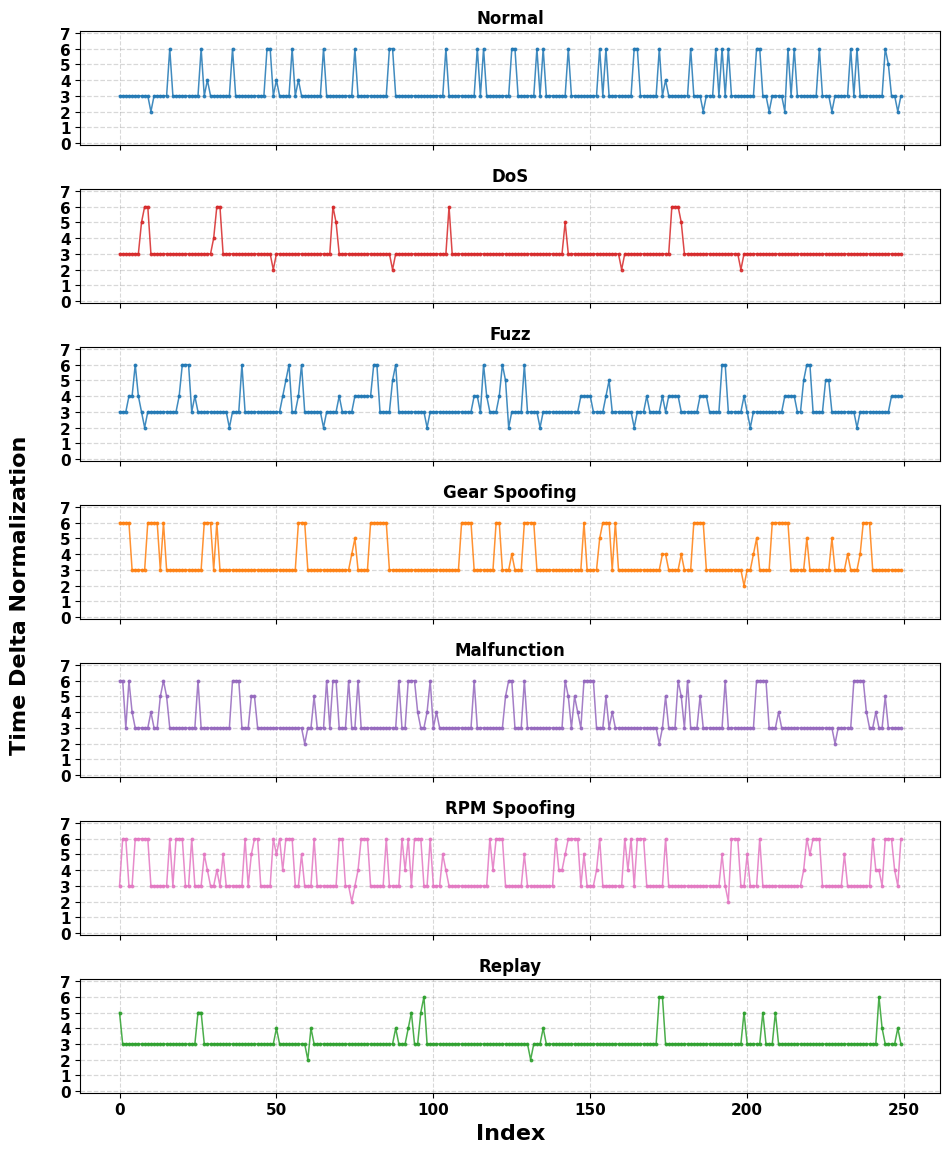

In [58]:
plot_category_chunks_shared_ylabel(
    category_chunks,
    feature_idx=0,
    shared_ylabel="Time Delta Normalization"
)

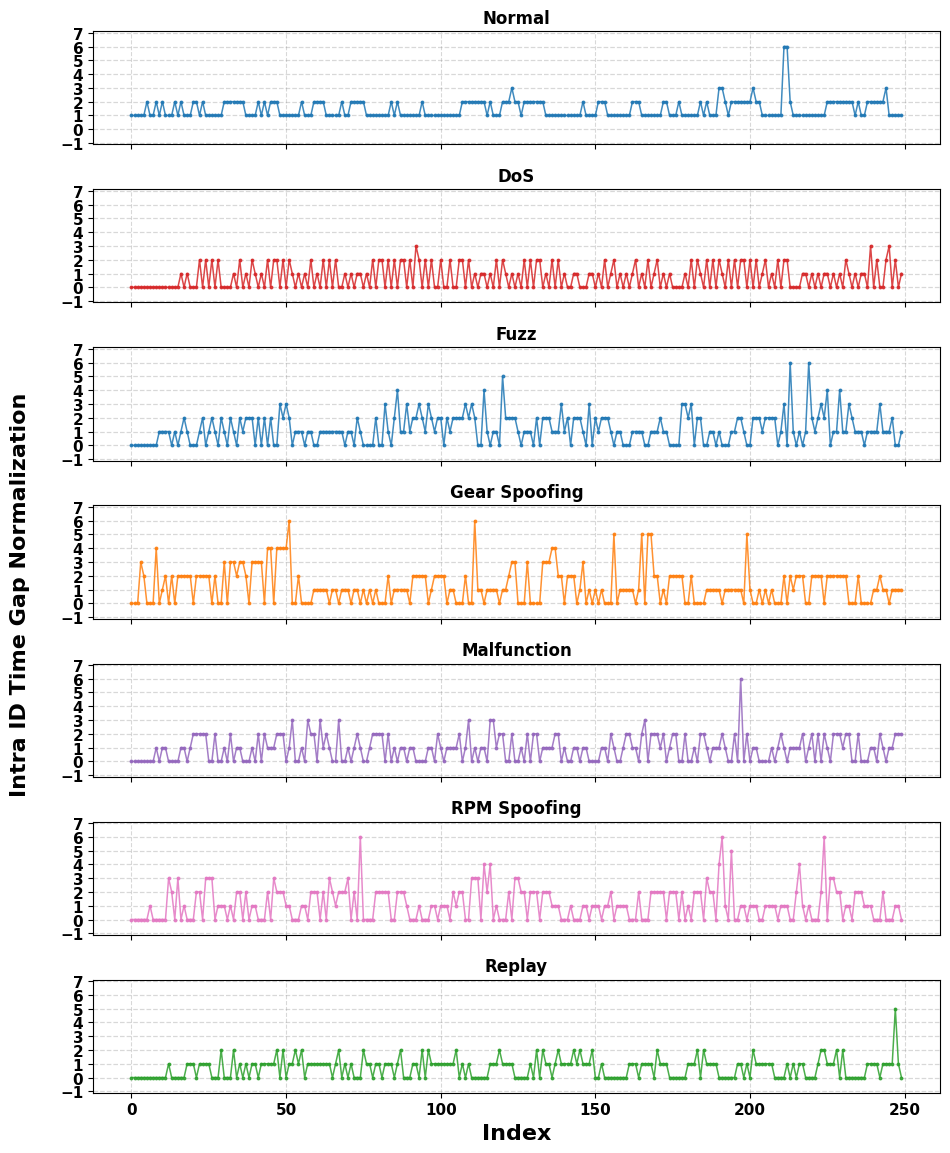

In [59]:
plot_category_chunks_shared_ylabel(
    category_chunks,
    feature_idx=1,
    shared_ylabel="Intra ID Time Gap Normalization"
)

In [60]:
import matplotlib.pyplot as plt
import numpy as np

def plot_category_chunks_shared_ylabel(
    category_chunks,
    feature_idx=0,
    shared_ylabel="Time Delta Normalization",
    figsize=(10, 12),
    x_tick_step=50,
    save_path=None
):
    desired_order = ["Normal", "DoS", "Fuzz", "Gear Spoofing", "Malfunction", "RPM Spoofing", "Replay"]
    categories = [c for c in desired_order if c in category_chunks]

    # display names only for plotting titles
    title_map = {
        "Normal": "Attack-Free",
        "DoS": "DoS",
        "Fuzz": "Fuzz",
        "Gear Spoofing": "Gear Spoofing",
        "Malfunction": "Malfunction",
        "RPM Spoofing": "RPM Spoofing",
        "Replay": "Replay",
    }

    color_map = {
        "Normal": "tab:blue",
        "DoS": "tab:red",
        "Fuzz": "teal",
        "Gear Spoofing": "tab:orange",
        "Malfunction": "tab:purple",
        "RPM Spoofing": "tab:pink",
        "Replay": "tab:green",
    }

    if feature_idx == 0:
        y_ticks = np.arange(0, 8, 1)    # 0 ~ 7
        y_min, y_max = -0.1, 7.1
    elif feature_idx == 1:
        y_ticks = np.arange(-1, 8, 1)   # -1 ~ 7
        y_min, y_max = -1.1, 7.1
    else:
        raise ValueError("feature_idx must be 0 or 1")

    max_len = max(len(category_chunks[c]) for c in categories)
    x_ticks = np.arange(0, max_len + 1, x_tick_step)

    fig, axes = plt.subplots(len(categories), 1, figsize=figsize, sharex=True)

    if len(categories) == 1:
        axes = [axes]

    for ax, category in zip(axes, categories):
        chunk = category_chunks[category]
        y = chunk[:, feature_idx]
        x = np.arange(len(y))

        ax.plot(
            x, y,
            linewidth=1.1,
            marker='o',
            markersize=1.8,
            alpha=0.85,
            color=color_map.get(category, None)
        )

        ax.set_title(title_map.get(category, category), fontsize=12, fontweight="bold")
        ax.set_ylim(y_min, y_max)
        ax.set_yticks(y_ticks)
        ax.set_xticks(x_ticks)

        ax.tick_params(axis='x', labelsize=11)
        ax.tick_params(axis='y', labelsize=11)

        if ax is not axes[-1]:
            ax.tick_params(axis='x', labelbottom=False)

        for tick in ax.get_xticklabels():
            tick.set_fontweight("bold")
        for tick in ax.get_yticklabels():
            tick.set_fontweight("bold")

        ax.grid(True, axis='y', linestyle='--', linewidth=0.9, alpha=0.3, color='gray')
        ax.grid(True, axis='x', linestyle='--', linewidth=0.8, alpha=0.3, color='gray')

    axes[-1].set_xlabel("Index", fontsize=16, fontweight="bold")
    fig.supylabel(shared_ylabel, fontsize=16, fontweight="bold", x=0.055)

    plt.tight_layout(rect=[0.055, 0.03, 1, 1])

    if save_path is not None:
        plt.savefig(save_path, format="pdf", bbox_inches="tight")

    plt.show()
    plt.close(fig)

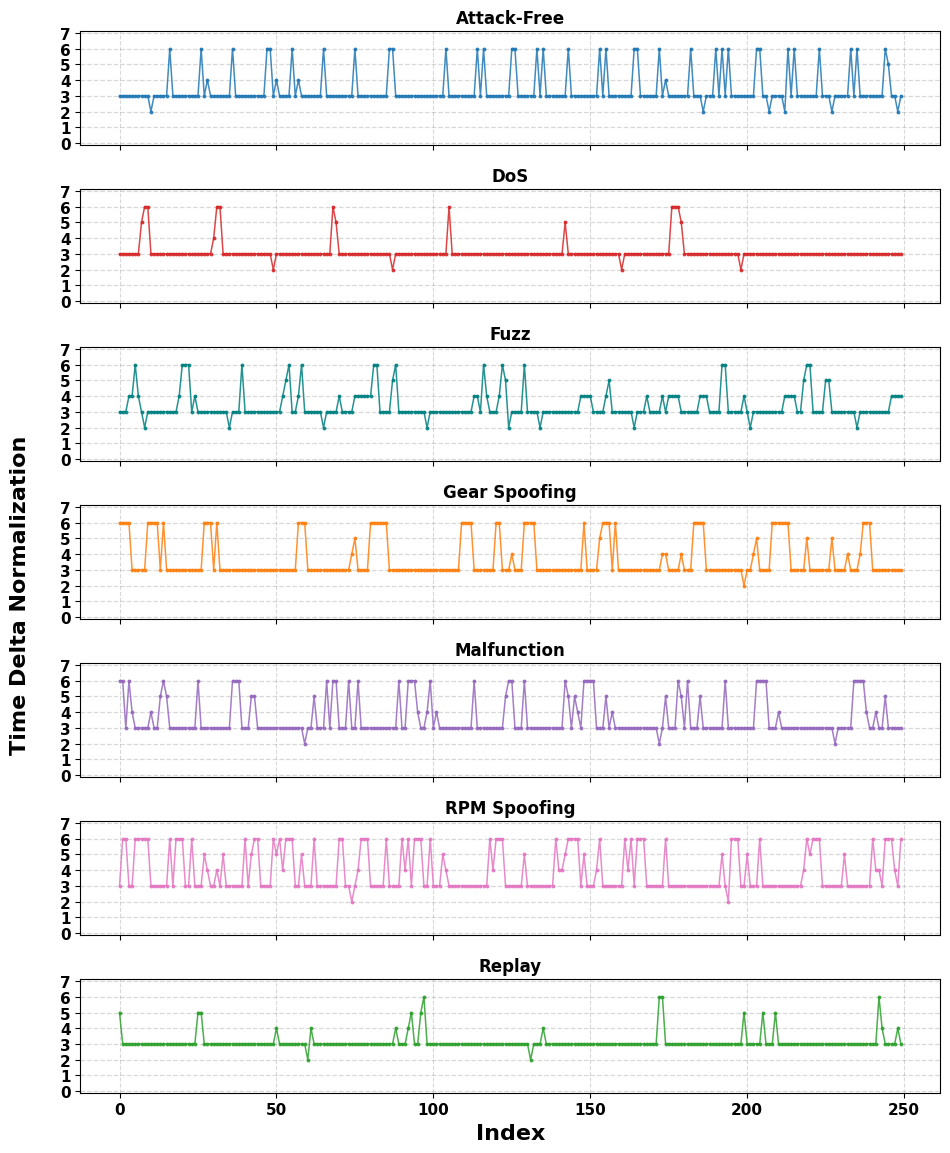

In [61]:
plot_category_chunks_shared_ylabel(
    category_chunks,
    feature_idx=0,
    shared_ylabel="Time Delta Normalization",
    figsize=(10, 12),
    x_tick_step=50,
    save_path="time_delta_normalization.pdf"
)

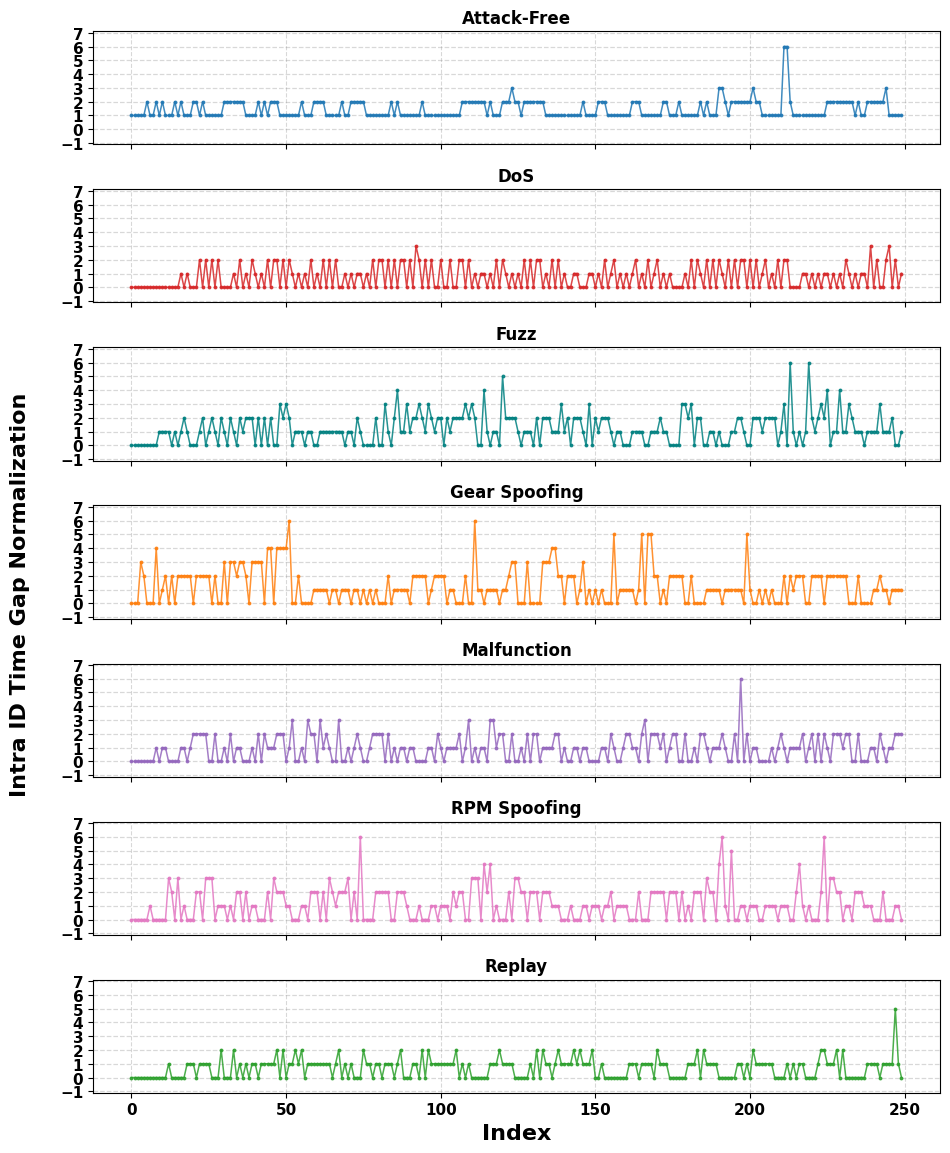

In [62]:
plot_category_chunks_shared_ylabel(
    category_chunks,
    feature_idx=1,
    shared_ylabel="Intra ID Time Gap Normalization",
    figsize=(10, 12),
    x_tick_step=50,
    save_path="intra_id_time_gap_normalization.pdf"
)